In [2]:
# 📌 1. Importer les librairies nécessaires
import pandas as pd

# 📌 2. Charger ton fichier CSV
# (remplace "ton_fichier.csv" par le vrai nom de ton fichier)
df = pd.read_csv("flight_data_with_delay_reasons.csv")

# 📌 3. Aperçu des données
print("=== Shape du dataset (lignes, colonnes) ===")
print(df.shape)

print("\n=== Noms des colonnes ===")
print(df.columns.tolist())

print("\n=== Types de données ===")
print(df.dtypes)

print("\n=== 5 premières lignes ===")
print(df.head())


=== Shape du dataset (lignes, colonnes) ===
(90250, 77)

=== Noms des colonnes ===
['VolId', 'NumVol', 'STDDate', 'STDHeure', 'Annule', 'RecordStatut', 'ARR_id', 'Compagnie_id', 'DEP_id', 'Terminal_id', 'TypeAvion_id', 'TypeVol_id', 'AssisteParTH', 'STD_datetime', 'Application', 'TypeOperation', 'TypeService', 'RecordStatut_typevol', 'CodeOACI', 'GroupeType', 'Constructeur', 'Notes_typeavion', 'RecordStatut_typeavion', 'Categorie_id', 'Fuselage_id', 'CodeIATA_arr', 'CodeOACI_arr', 'Nom_arr', 'Elevation_arr', 'Latitude_arr', 'Longitude_arr', 'RecordStatut_arr', 'CodeIATA_dep', 'CodeOACI_dep', 'Nom_dep', 'Elevation_dep', 'Latitude_dep', 'Longitude_dep', 'Chart_dep', 'RecordStatut_dep', 'ServiceId_service', 'Description_service', 'RecordStatut_service', 'Aeroport_id_service', 'Departement_id_service', 'Vol_id', 'ATD_ts', 'departure_delay_min', 'departure_delayed', 'arrival_delayed', 'STD_datetime_rounded', 'weather_time', 'temp', 'prcp', 'wdir', 'wspd', 'pres', 'coco', 'Year', 'Quarter', 

In [3]:
# 📌 1. Conversion des colonnes de dates et heures
df["STD_datetime"] = pd.to_datetime(df["STD_datetime"], errors="coerce")
df["STDDate"] = pd.to_datetime(df["STDDate"], errors="coerce")

# Certaines colonnes météo ont aussi des timestamps :
df["weather_time"] = pd.to_datetime(df["weather_time"], errors="coerce")
df["ATD_ts"] = pd.to_datetime(df["ATD_ts"], errors="coerce")
df["STD_datetime_rounded"] = pd.to_datetime(df["STD_datetime_rounded"], errors="coerce")

# 📌 2. Colonnes temporelles dérivées
df["Hour"] = df["STD_datetime"].dt.hour
df["Day"] = df["STD_datetime"].dt.day
df["Weekday"] = df["STD_datetime"].dt.day_name()
df["Month"] = df["STD_datetime"].dt.month
df["Year"] = df["STD_datetime"].dt.year

# 📌 3. Vérification des retards
# (certaines colonnes existent déjà mais on s'assure)
df["departure_delay_min"] = pd.to_numeric(df["departure_delay_min"], errors="coerce")
df["DepDelayMinutes"] = pd.to_numeric(df["DepDelayMinutes"], errors="coerce")

# Boolean binaire déjà présent : departure_delayed
df["departure_delayed"] = df["departure_delayed"].astype(bool)

# 📌 4. Nettoyage des causes de retard
df["DL1_desc"] = df["DL1_desc"].fillna("Unknown")
df["DL2_desc"] = df["DL2_desc"].fillna("Unknown")
df["DL3_desc"] = df["DL3_desc"].fillna("Unknown")

# 📌 5. Vérif finale
print("Dates min-max :", df["STD_datetime"].min(), "->", df["STD_datetime"].max())
print("\nRetard moyen :", df["departure_delay_min"].mean())
print("\nValeurs uniques - Compagnie :", df["Compagnie_id"].nunique())
print("Valeurs uniques - Aéroports départ :", df["DEP_id"].nunique())
print("Valeurs uniques - Aéroports arrivée :", df["ARR_id"].nunique())
print("\nTop 5 compagnies :")
print(df["Compagnie_id"].value_counts().head())


Dates min-max : 2021-09-09 14:00:00 -> 2025-01-24 12:50:00

Retard moyen : 31.22601440443213

Valeurs uniques - Compagnie : 107
Valeurs uniques - Aéroports départ : 17
Valeurs uniques - Aéroports arrivée : 246

Top 5 compagnies :
Compagnie_id
TU    31259
TO    10138
UG     8196
AF     4189
YL     3967
Name: count, dtype: int64


In [4]:
# Cell 1 - Configuration & imports
# Remplace CSV_PATH par le chemin de ton fichier si nécessaire.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Couleurs / thème
RED_HEX = "#E52928"  # rgb(229,41,40)
BG = "#111111"        # arrière-plan global (sombre)
AX_BG = "#1a1a1a"     # arrière-plan des axes
TEXT_COLOR = "white"
TICK_COLOR = "white"

# Chemin par défaut (à modifier si besoin)
CSV_PATH = Path("flight_data_with_delay_reasons.csv")

# Charger le dataframe si variable df non définie
if 'df' not in globals():
    if CSV_PATH.exists():
        df = pd.read_csv(CSV_PATH, low_memory=False)
        print(f"✓ CSV chargé depuis: {CSV_PATH}")
    else:
        raise FileNotFoundError(
            f"Fichier CSV non trouvé. Modifie la variable CSV_PATH au début du fichier : {CSV_PATH}")

# Assurer les colonnes datetime
for col in ['STD_datetime','STDDate','STD_datetime_rounded']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Si STD_datetime absent ou vide, essayer de le reconstruire à partir de STDDate + STDHeure
if 'STD_datetime' not in df.columns or df['STD_datetime'].isna().all():
    if 'STDDate' in df.columns and 'STDHeure' in df.columns:
        df['STDDate'] = pd.to_datetime(df['STDDate'], errors='coerce')
        # STDHeure peut être au format HH:MM:SS ou HH:MM
        df['STDHeure_parsed'] = pd.to_datetime(df['STDHeure'].astype(str), errors='coerce', format='%H:%M', exact=False)
        mask = df.get('STD_datetime', pd.Series(pd.NaT, index=df.index)).isna()
        df.loc[mask, 'STD_datetime'] = pd.to_datetime(
            df.loc[mask, 'STDDate'].dt.strftime('%Y-%m-%d') + ' ' +
            df.loc[mask, 'STDHeure_parsed'].dt.strftime('%H:%M:%S'), errors='coerce')

# Colonnes dérivées utiles
if 'STD_datetime' in df.columns:
    df['Month'] = df['STD_datetime'].dt.month
    df['std_date'] = df['STD_datetime'].dt.date
    df['Hour'] = df['STD_datetime'].dt.hour
else:
    # fallback si les colonnes n'existent pas
    if 'STDDate' in df.columns:
        df['Month'] = pd.to_datetime(df['STDDate'], errors='coerce').dt.month

# Fonction utilitaire pour styliser les axes
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(AX_BG)
    ax.figure.set_facecolor(BG)
    if title:
        ax.set_title(title, color=RED_HEX, fontsize=14, weight='bold')
    if xlabel:
        ax.set_xlabel(xlabel, color=TEXT_COLOR)
    if ylabel:
        ax.set_ylabel(ylabel, color=TEXT_COLOR)
    ax.tick_params(colors=TICK_COLOR)
    for spine in ax.spines.values():
        spine.set_color(RED_HEX)
    ax.grid(True, color='gray', alpha=0.2)




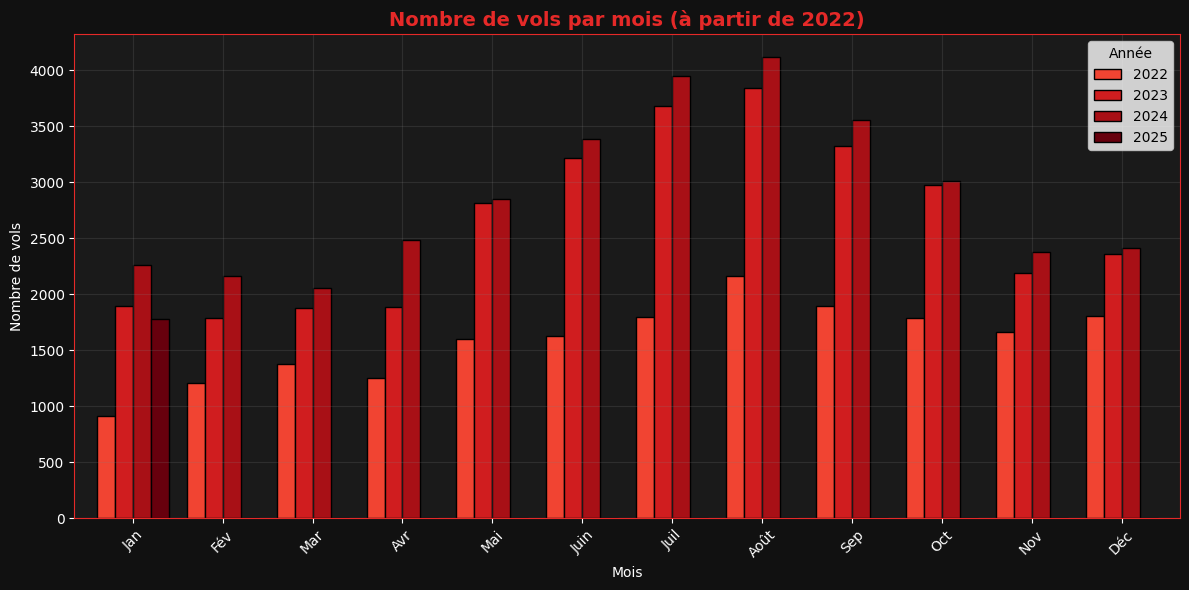

In [5]:
# -------------------------------------------------------------------------
# Cell - Nombre de vols par mois avec couleurs par année (depuis 2022)
# -------------------------------------------------------------------------
import matplotlib.cm as cm
import numpy as np

# Filtrer les années >= 2022
df_filtered = df[df['Year'] >= 2022]

# Grouper par mois et année
monthly_counts = df_filtered.groupby(['Month','Year']).size().unstack(fill_value=0)

# Labels des mois
month_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

# Palette de couleurs pour chaque année
colors = cm.Reds(np.linspace(0.6, 1, len(monthly_counts.columns)))

# Création du bar chart groupé
fig, ax = plt.subplots(figsize=(12,6))
monthly_counts.plot(
    kind='bar',
    ax=ax,
    color=colors,
    edgecolor='black',
    width=0.8
)

# Styling
style_ax(ax, title='Nombre de vols par mois (à partir de 2022)', xlabel='Mois', ylabel='Nombre de vols')

# Remplacer ticks X par noms des mois
ax.set_xticklabels(month_labels, rotation=45)

plt.legend(title='Année')
plt.tight_layout()
plt.show()


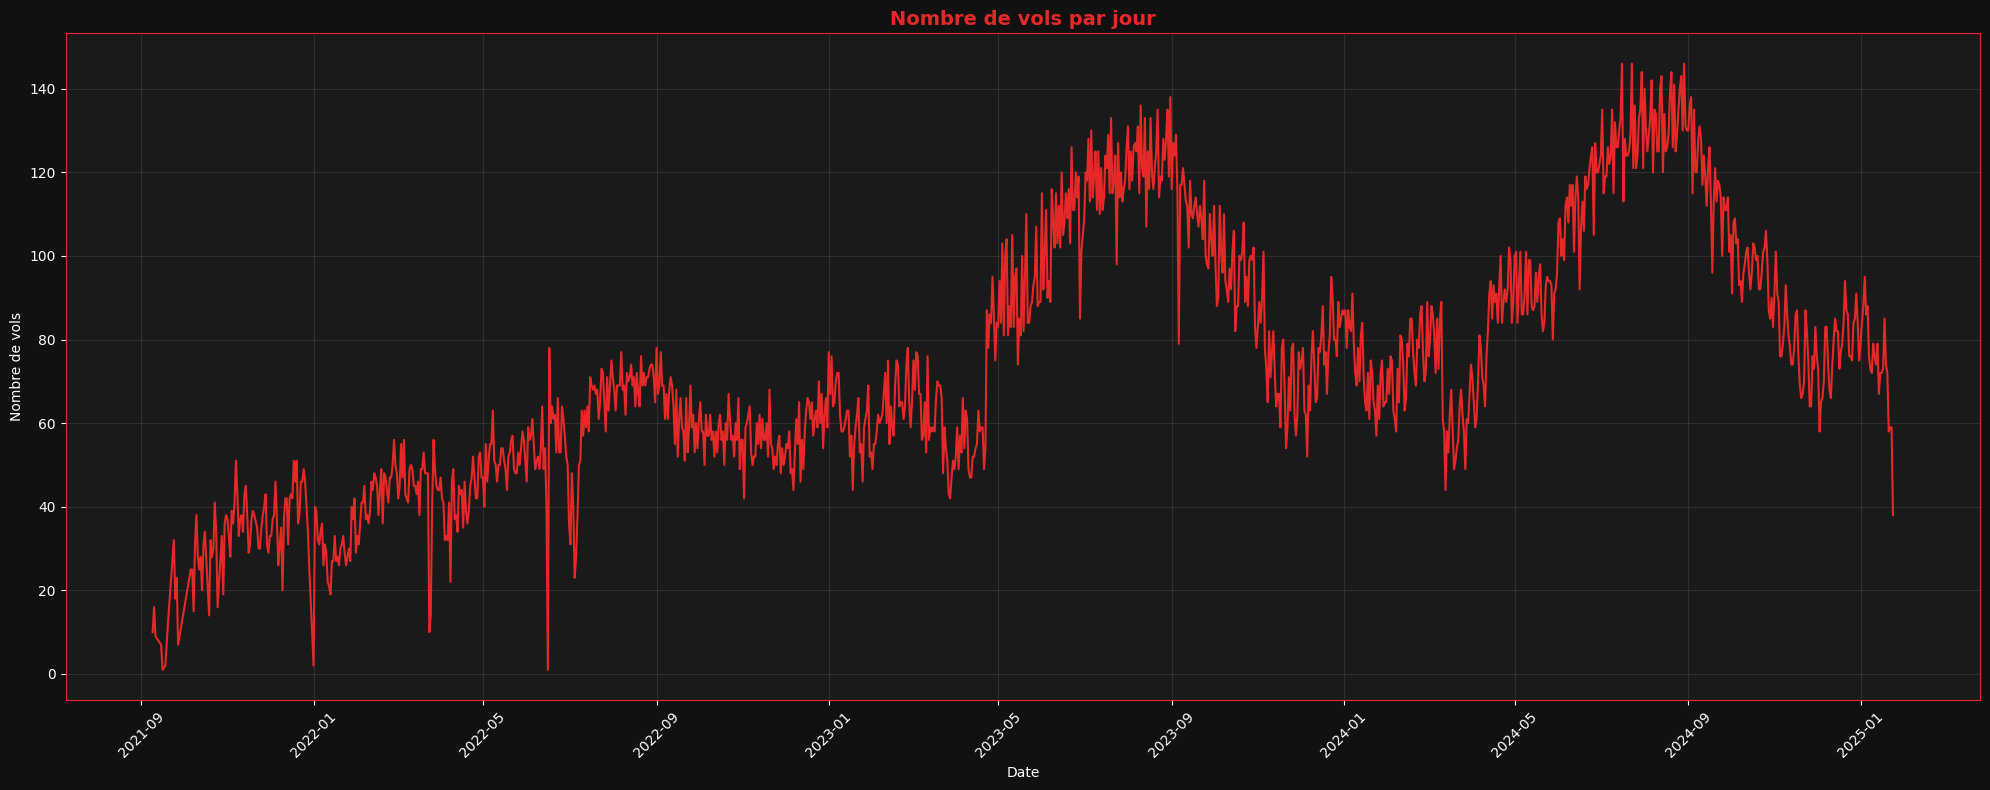

In [6]:
# -------------------------------------------------------------------------
# Cell 3 - Nombre de vols par jour (time series)
# -------------------------------------------------------------------------
counts_day = df.groupby('std_date').size().sort_index()
fig, ax = plt.subplots(figsize=(20,8))
ax.plot(counts_day.index, counts_day.values, color=RED_HEX)
style_ax(ax, title='Nombre de vols par jour', xlabel='Date', ylabel='Nombre de vols')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



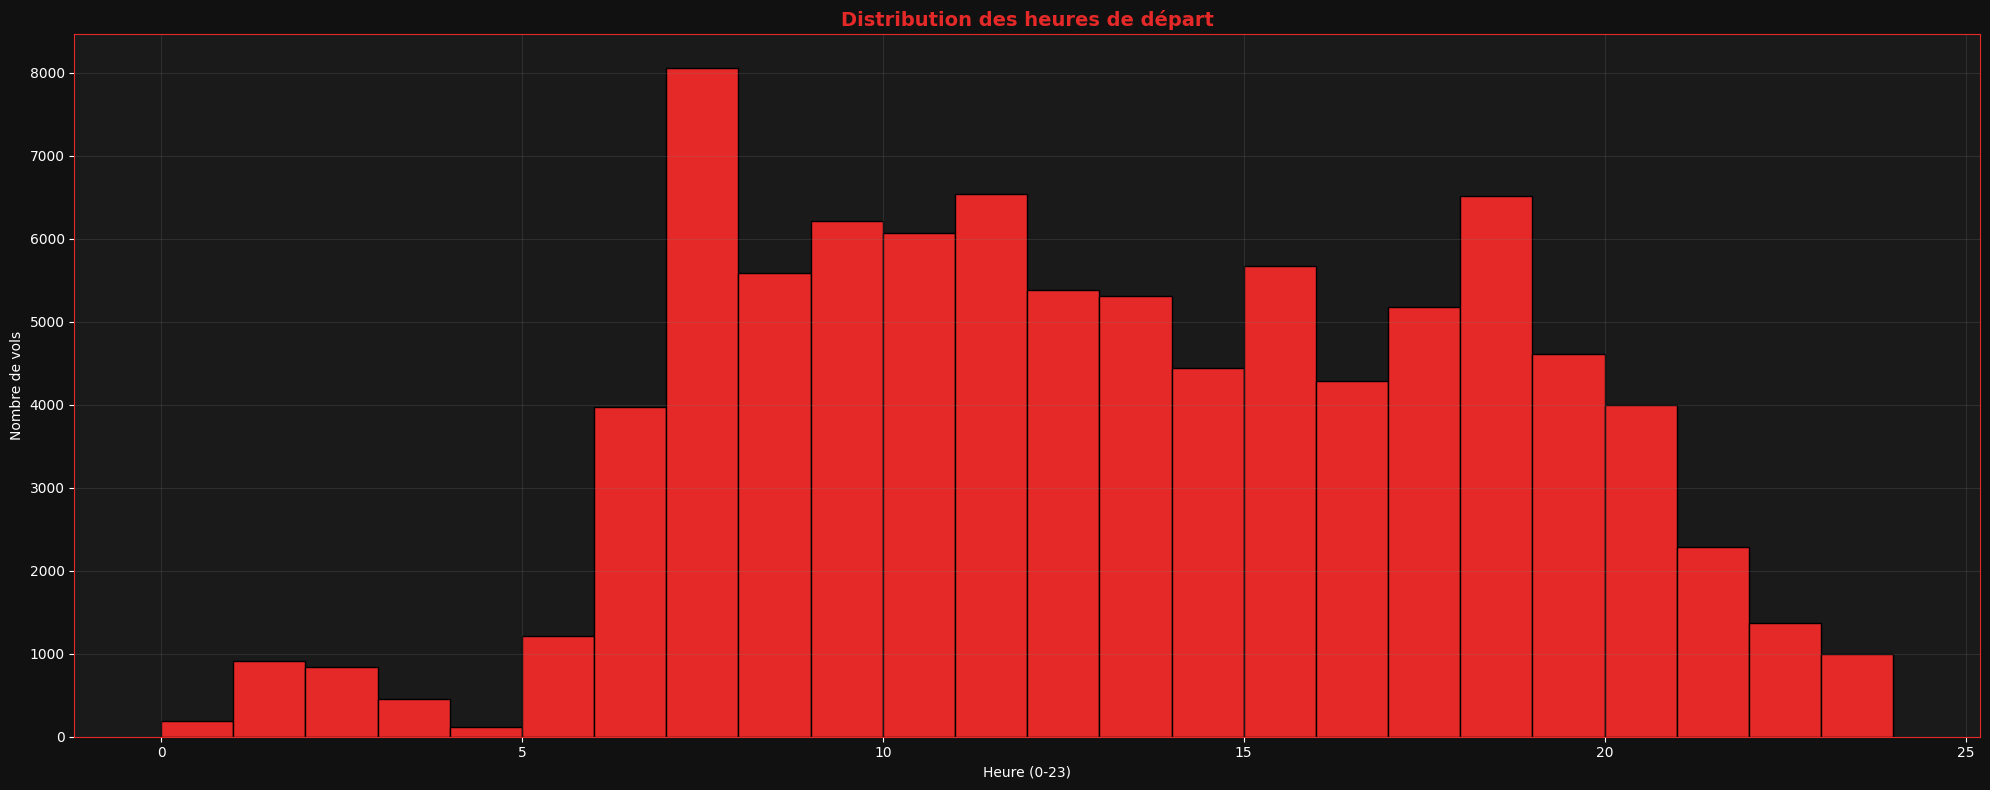

In [7]:

# -------------------------------------------------------------------------
# Cell 4 - Distribution des heures de départ (histogram)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20,8))
hours = df['Hour'].dropna().astype(int)
ax.hist(hours, bins=range(0,25), color=RED_HEX, edgecolor='black')
style_ax(ax, title='Distribution des heures de départ', xlabel='Heure (0-23)', ylabel='Nombre de vols')
plt.tight_layout()
plt.show()




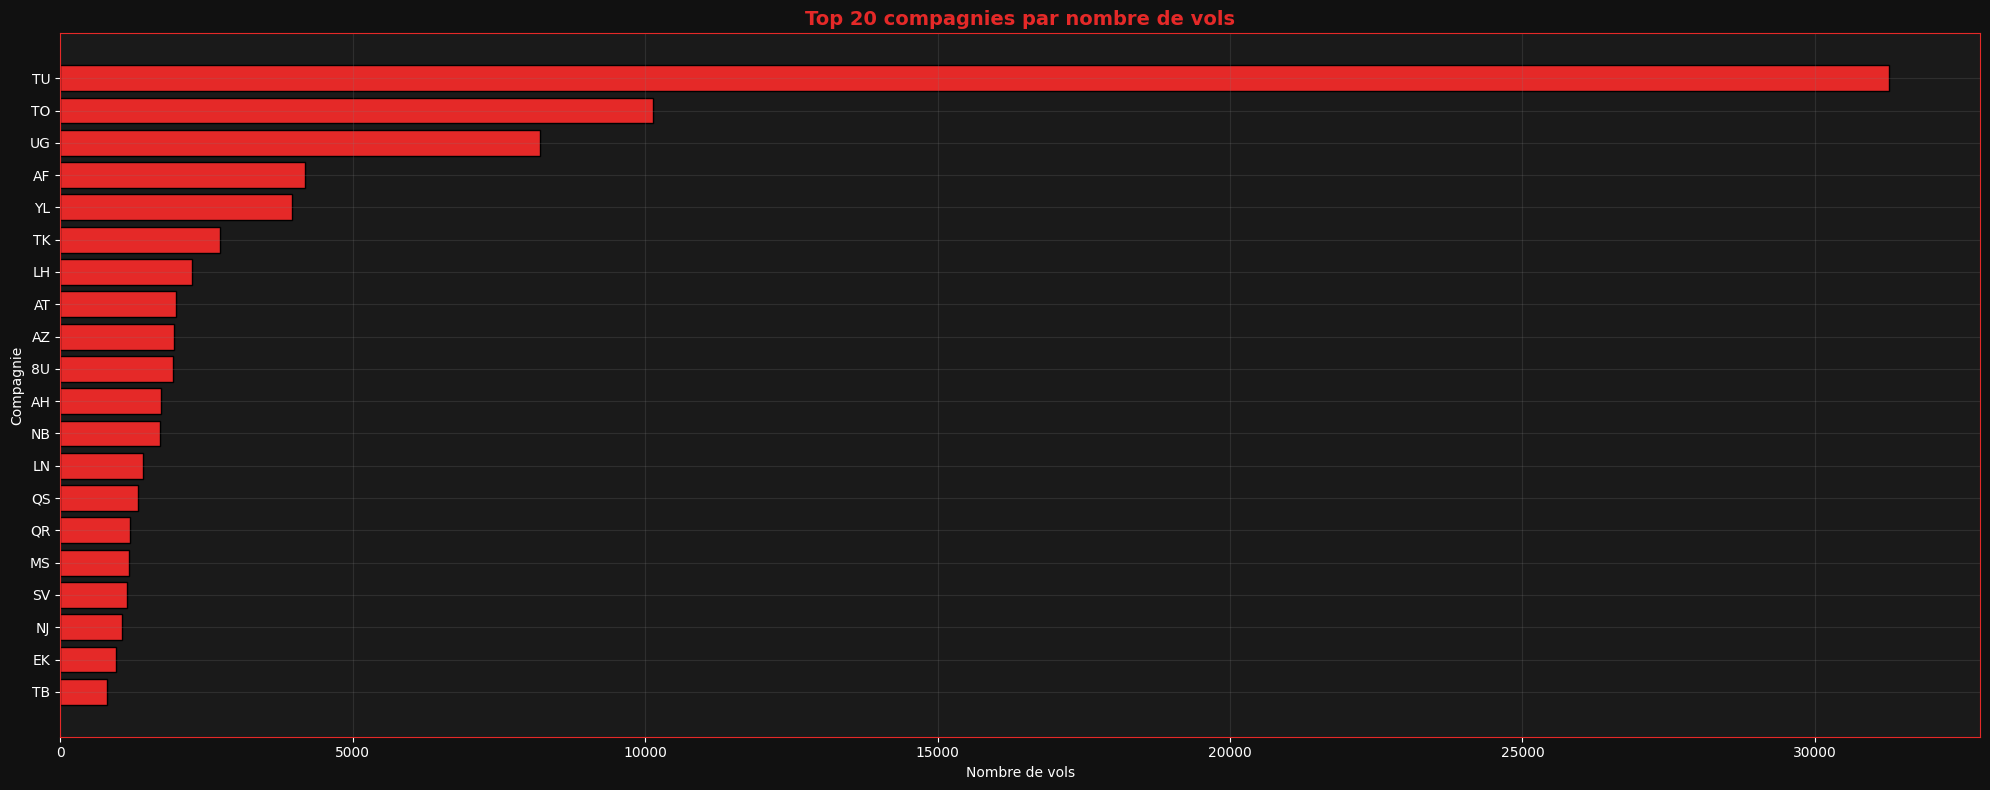

In [8]:
# -------------------------------------------------------------------------
# Cell 5 - Top 20 compagnies par nombre de vols (bar horizontal)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20,8))
top = df['Compagnie_id'].value_counts().head(20)
ax.barh(top.index[::-1], top.values[::-1], color=RED_HEX, edgecolor='black')
style_ax(ax, title='Top 20 compagnies par nombre de vols', xlabel='Nombre de vols', ylabel='Compagnie')
plt.tight_layout()
plt.show()




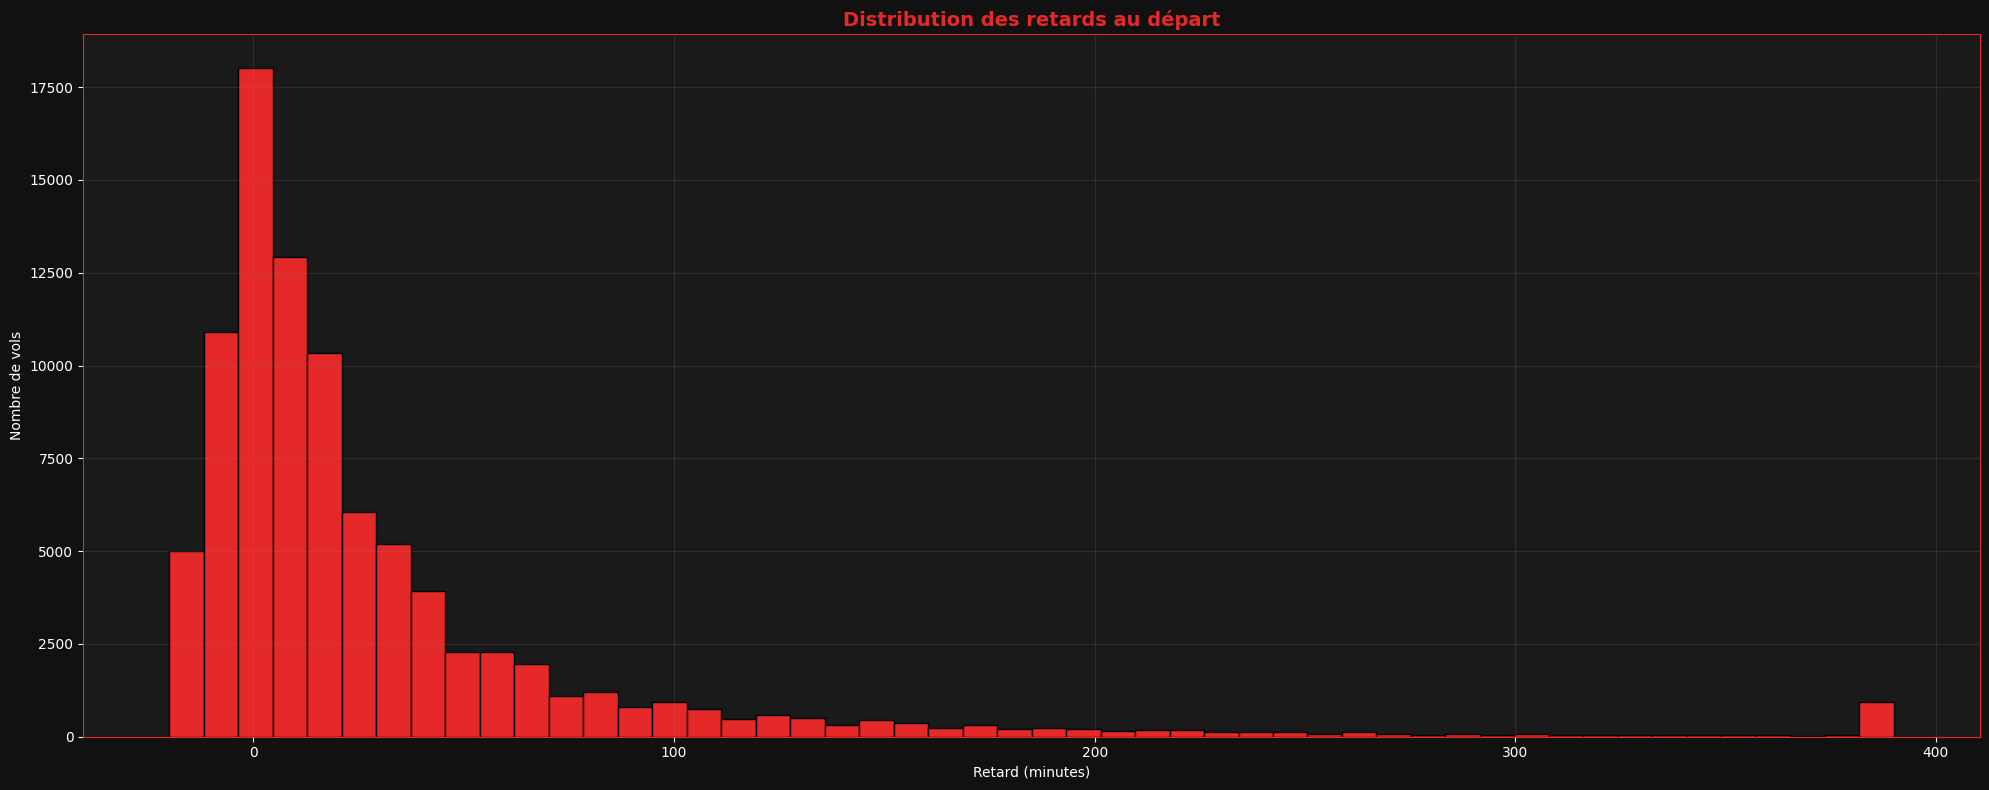

In [9]:
# -------------------------------------------------------------------------
# Cell 6 - Distribution des retards au départ (hist, cap à 300 min pour lisibilité)
# -------------------------------------------------------------------------
if 'departure_delay_min' in df.columns:
    delays = pd.to_numeric(df['departure_delay_min'], errors='coerce').dropna()
    delays_clipped = delays.clip(upper=500)
    fig, ax = plt.subplots(figsize=(20,8))
    ax.hist(delays_clipped, bins=50, color=RED_HEX, edgecolor='black')
    style_ax(ax, title='Distribution des retards au départ', xlabel='Retard (minutes)', ylabel='Nombre de vols')
    plt.tight_layout()
    plt.show()
else:
    print("Colonne 'departure_delay_min' non trouvée dans le dataframe.")


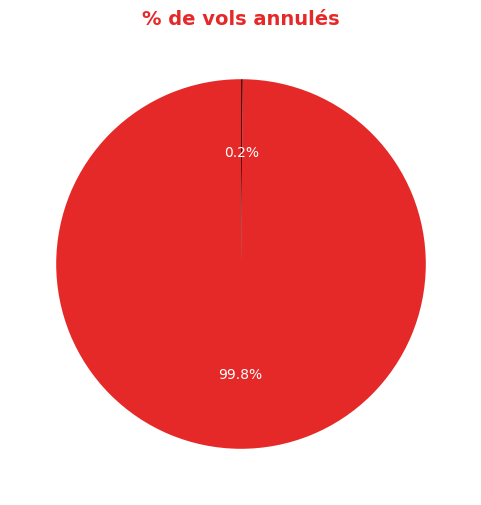

In [10]:
# -------------------------------------------------------------------------
# Cell - % de vols annulés
# -------------------------------------------------------------------------
annule_counts = df['Annule'].value_counts()
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(annule_counts, labels=annule_counts.index.map({True:'Annulé', False:'Réalisé'}),
       autopct='%1.1f%%', colors=[RED_HEX, '#660000'], startangle=90, textprops={'color':'white'})
ax.set_title('% de vols annulés', color=RED_HEX, fontsize=14, weight='bold')
plt.show()


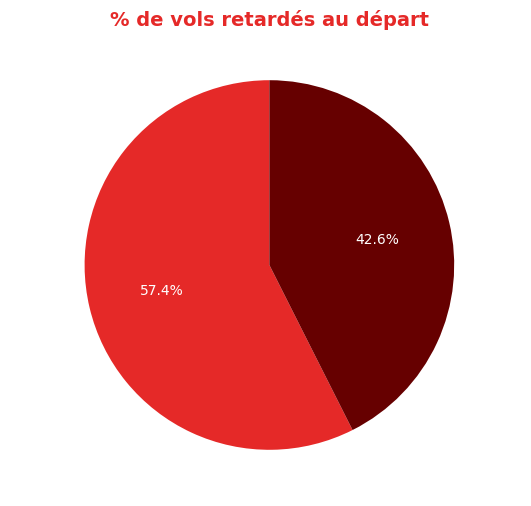

In [11]:
# -------------------------------------------------------------------------
# Cell - % de vols retardés au départ
# -------------------------------------------------------------------------
retard_counts = df['departure_delayed'].value_counts()
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(retard_counts, labels=retard_counts.index.map({True:'Retardé', False:'À l\'heure'}),
       autopct='%1.1f%%', colors=[RED_HEX, '#660000'], startangle=90, textprops={'color':'white'})
ax.set_title('% de vols retardés au départ', color=RED_HEX, fontsize=14, weight='bold')
plt.show()


) missing from font(s) DejaVu Sans.ss8d80000gn/T/ipykernel_9307/1164843603.py:8: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.n /.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


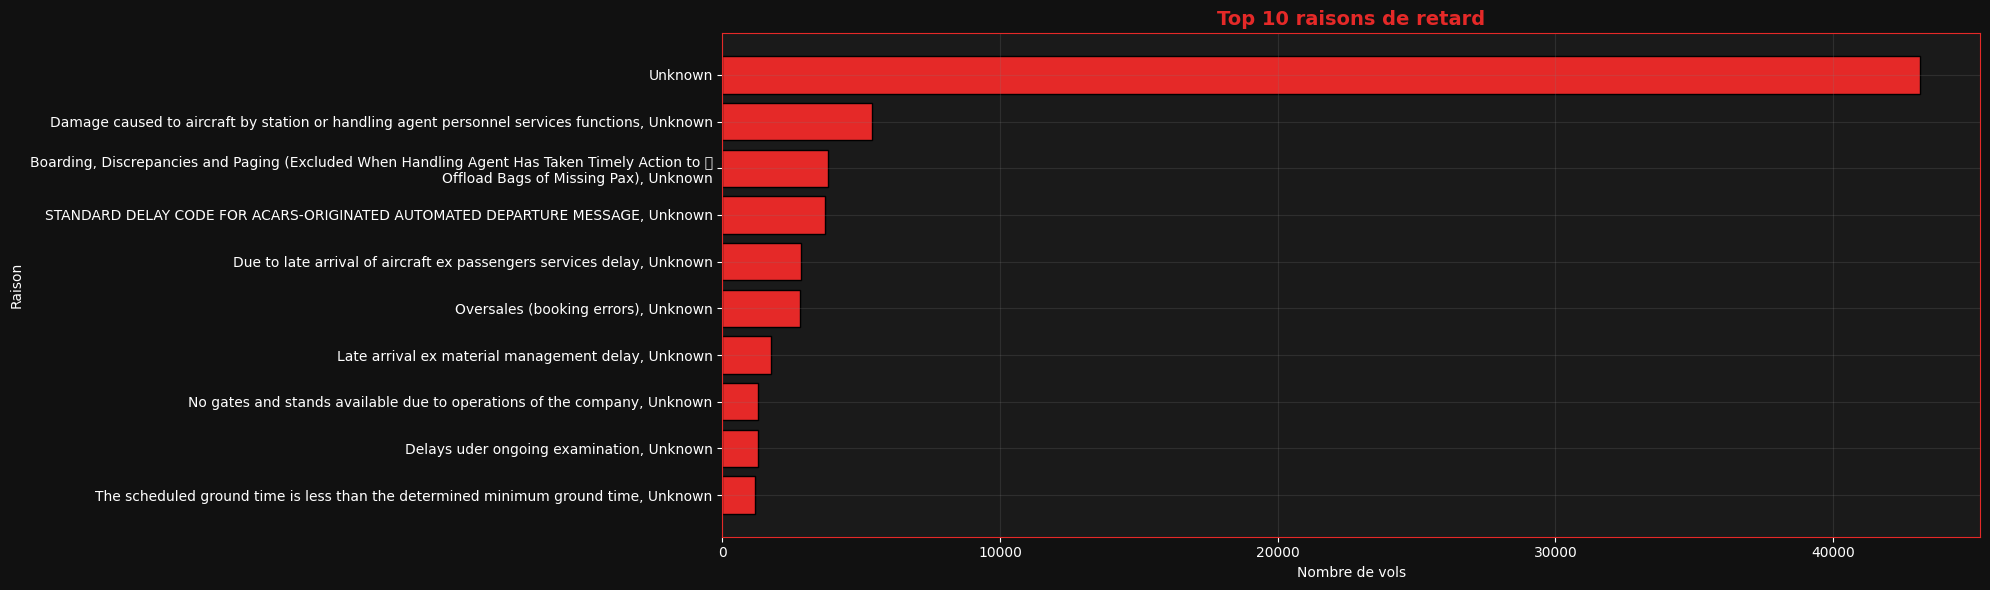

In [12]:
# -------------------------------------------------------------------------
# Cell - Top 10 raisons de retard
# -------------------------------------------------------------------------
top_reasons = df['DL1_desc'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(20,6))
ax.barh(top_reasons.index[::-1], top_reasons.values[::-1], color=RED_HEX, edgecolor='black')
style_ax(ax, title='Top 10 raisons de retard', xlabel='Nombre de vols', ylabel='Raison')
plt.tight_layout()
plt.show()


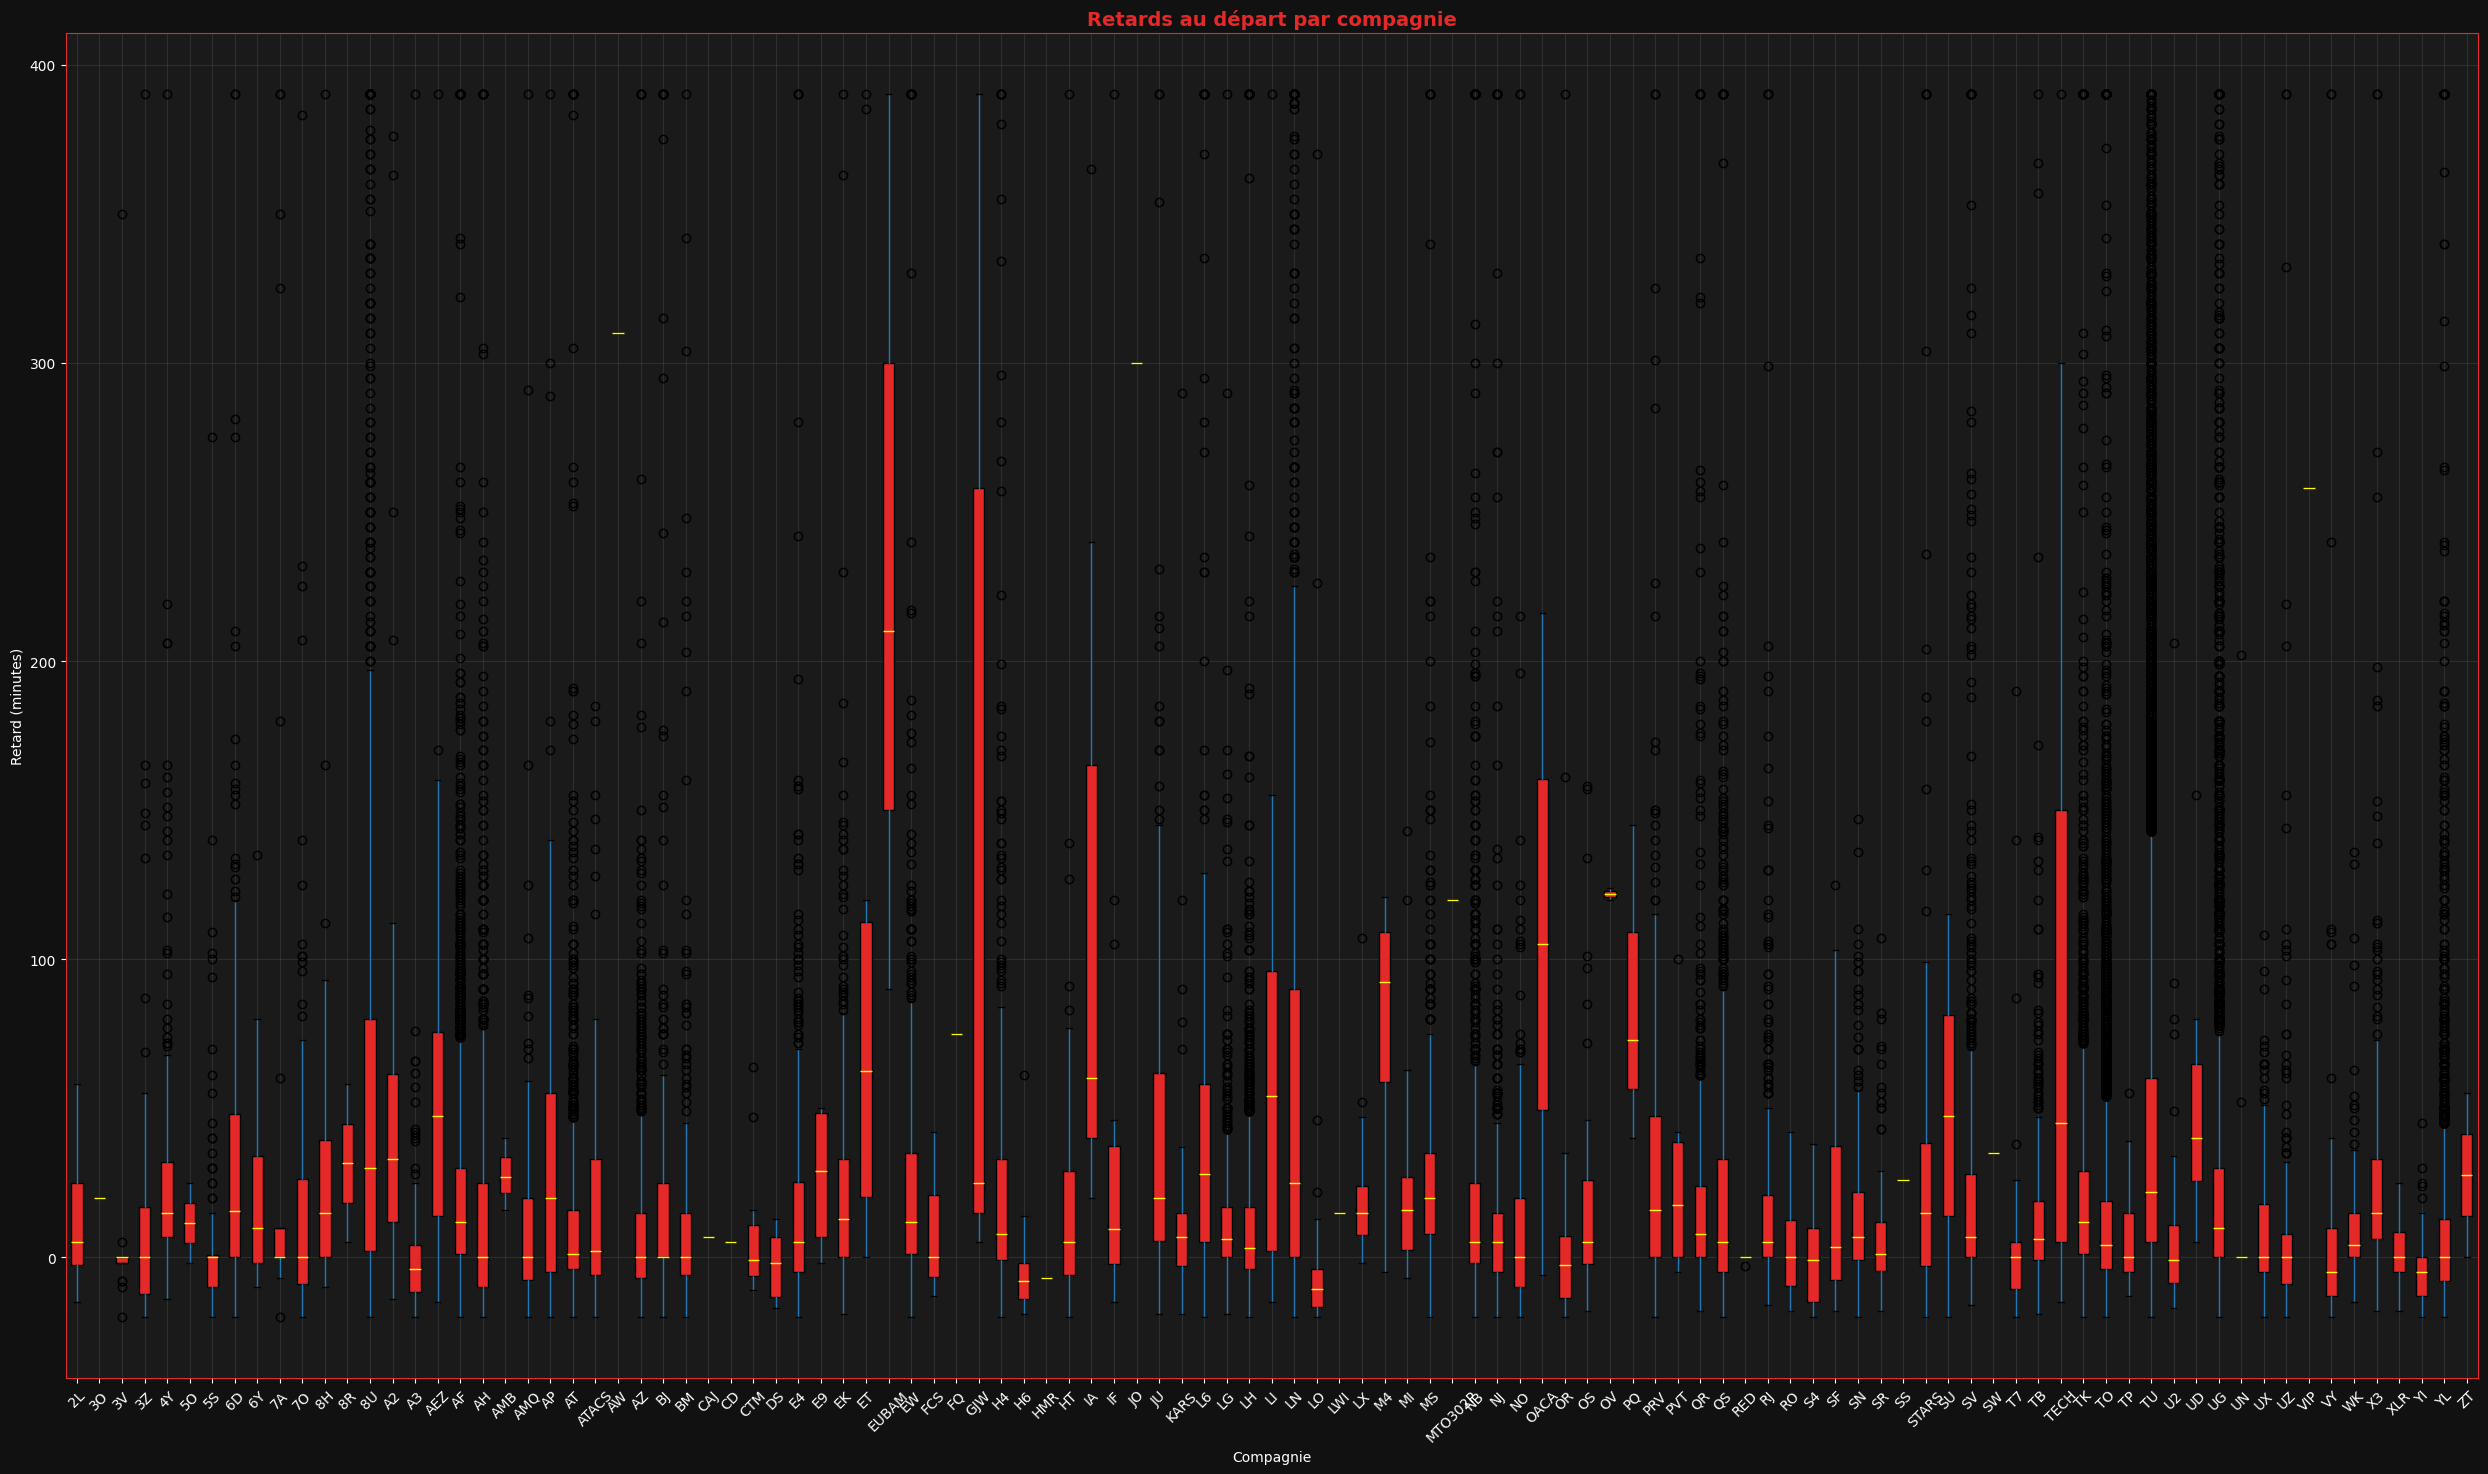

In [13]:
# -------------------------------------------------------------------------
# Cell - Retards par compagnie
# -------------------------------------------------------------------------
if 'departure_delay_min' in df.columns:
    fig, ax = plt.subplots(figsize=(25,15))
    df_box = df[['Compagnie_id','departure_delay_min']].dropna()
    df_box.boxplot(column='departure_delay_min', by='Compagnie_id', ax=ax, grid=False, patch_artist=True,
                   boxprops=dict(facecolor=RED_HEX, color='black'),
                   medianprops=dict(color='yellow'))
    style_ax(ax, title='Retards au départ par compagnie', xlabel='Compagnie', ylabel='Retard (minutes)')
    plt.suptitle('')  # Supprimer le titre automatique de pandas
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


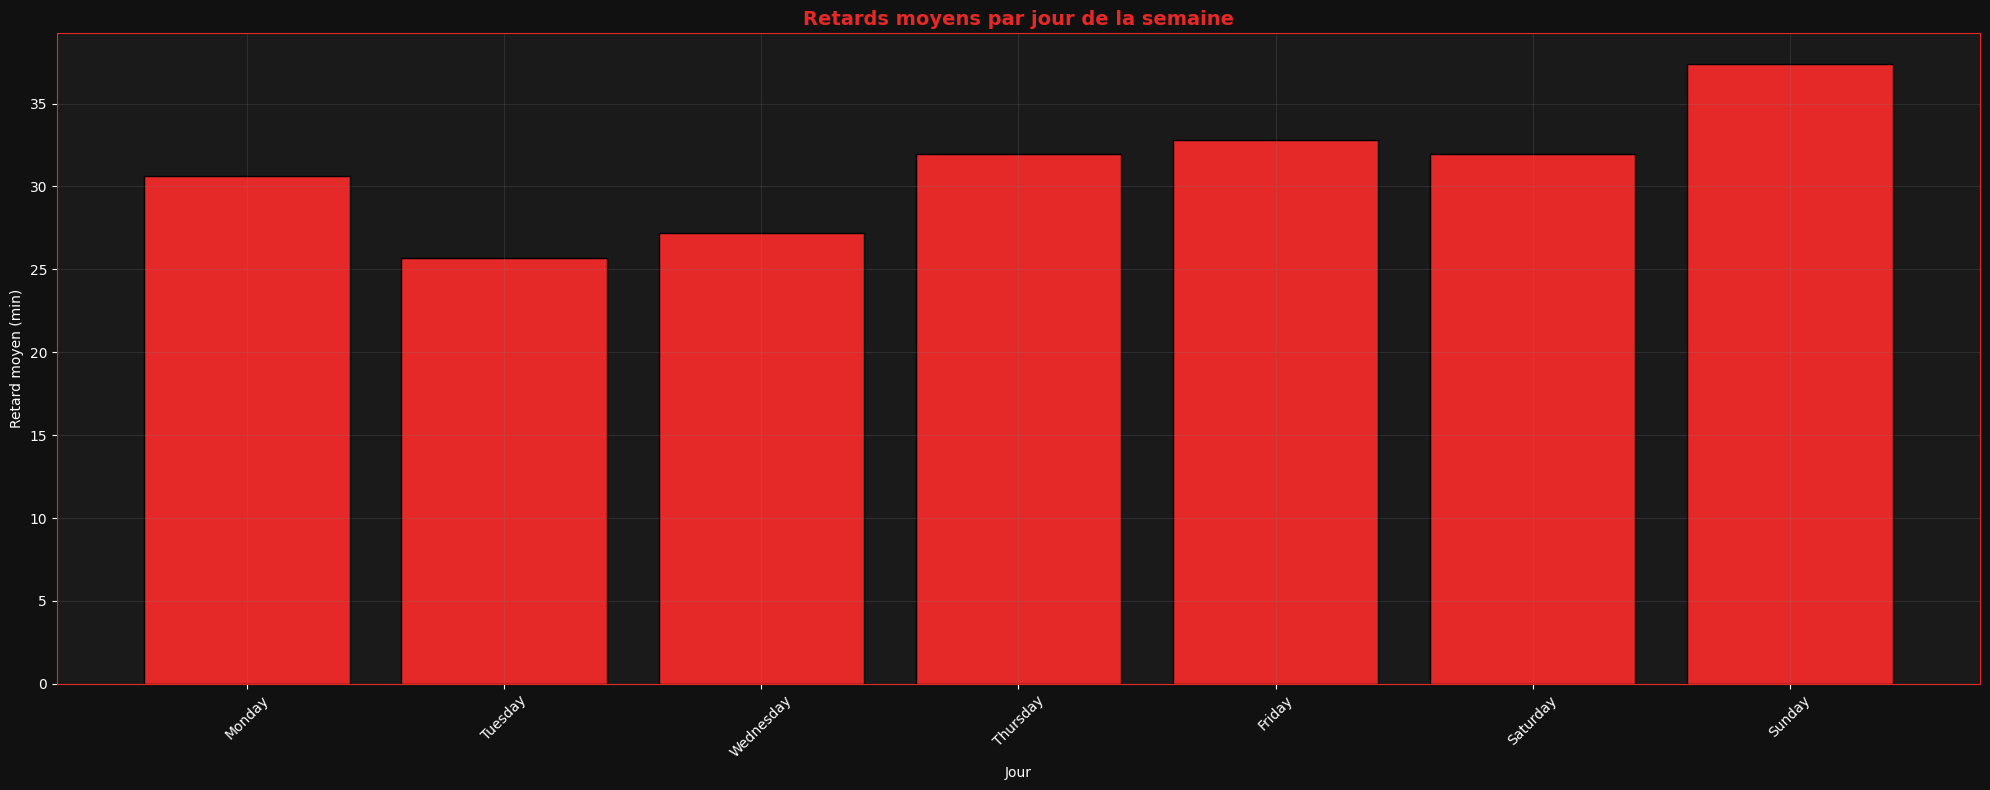

In [14]:
# -------------------------------------------------------------------------
# Cell - Retards moyens par jour de la semaine
# -------------------------------------------------------------------------
if 'STD_datetime' in df.columns and 'departure_delay_min' in df.columns:
    df['Weekday'] = df['STD_datetime'].dt.day_name()
    weekday_avg = df.groupby('Weekday')['departure_delay_min'].mean()
    # Réordonner les jours
    days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    weekday_avg = weekday_avg.reindex(days_order)
    
    fig, ax = plt.subplots(figsize=(20,8))
    ax.bar(weekday_avg.index, weekday_avg.values, color=RED_HEX, edgecolor='black')
    style_ax(ax, title='Retards moyens par jour de la semaine', xlabel='Jour', ylabel='Retard moyen (min)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


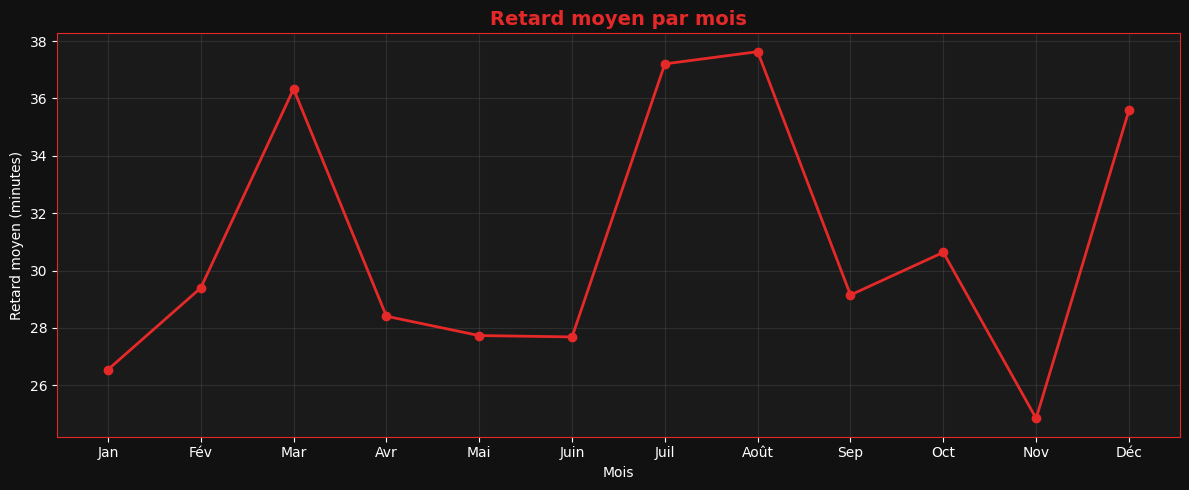

In [15]:
# -------------------------------------------------------------------------
# Cell - Retards moyens par mois
# -------------------------------------------------------------------------
if 'Month' in df.columns and 'departure_delay_min' in df.columns:
    monthly_avg = df.groupby('Month')['departure_delay_min'].mean()
    month_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
    
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(month_labels, monthly_avg.values, color=RED_HEX, marker='o', linewidth=2)
    style_ax(ax, title='Retard moyen par mois', xlabel='Mois', ylabel='Retard moyen (minutes)')
    plt.tight_layout()
    plt.show()


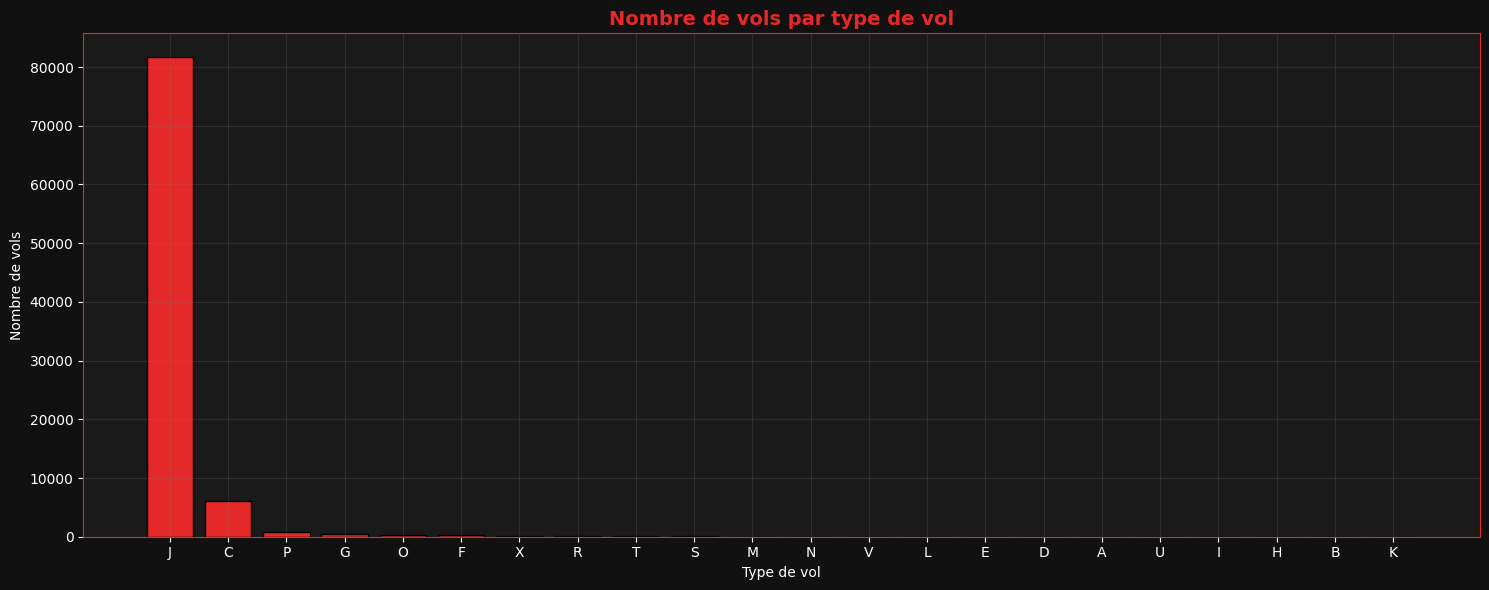

In [16]:
# -------------------------------------------------------------------------
# Cell - Nombre de vols par type de vol
# -------------------------------------------------------------------------
type_counts = df['TypeVol_id'].value_counts()
fig, ax = plt.subplots(figsize=(15,6))
ax.bar(type_counts.index, type_counts.values, color=RED_HEX, edgecolor='black')
style_ax(ax, title='Nombre de vols par type de vol', xlabel='Type de vol', ylabel='Nombre de vols')
plt.tight_layout()
plt.show()


In [20]:
import folium
airport_stats = df.groupby(['Nom_arr','Latitude_arr','Longitude_arr']).agg(
    nb_vols=('VolId','count'),
    retard_moyen=('departure_delay_min','mean'),
    pct_annules=('Annule','mean')
).reset_index()
# Centre carte
center_lat = df['Latitude_arr'].mean()
center_lon = df['Longitude_arr'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=4)

# Ajouter les aéroports avec popup
for idx, row in airport_stats.iterrows():
    folium.CircleMarker(
        location=[row['Latitude_arr'], row['Longitude_arr']],
        radius=5 + row['nb_vols']/1000,  # taille relative
        color='#E52928',
        fill=True,
        fill_color='#E52928',
        fill_opacity=0.7,
        popup=(f"{row['Nom_arr']}<br>"
               f"Vols: {row['nb_vols']}<br>"
               f"Retard moyen: {row['retard_moyen']:.1f} min<br>"
               f"% Annulés: {row['pct_annules']*100:.1f}%")
    ).add_to(m)

m


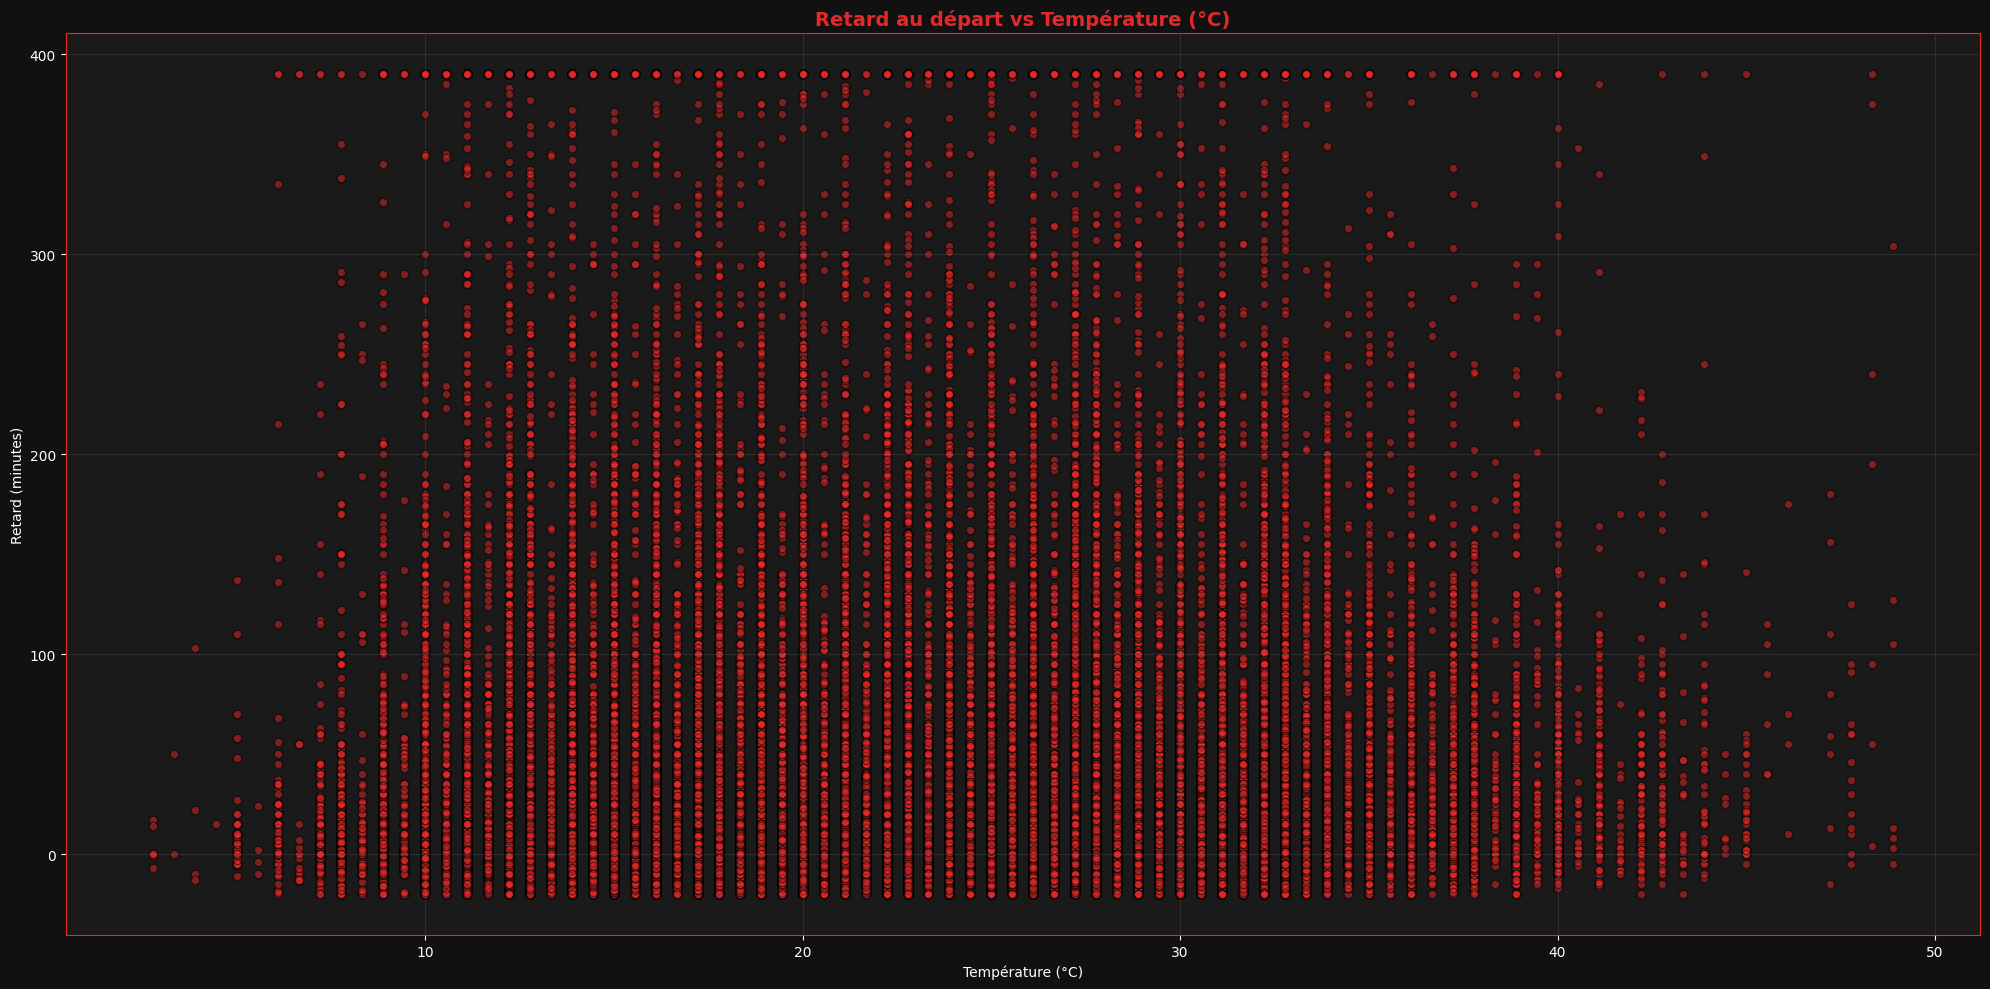

In [23]:
# Convert Fahrenheit to Celsius
df['tempC'] = (df['tempF'] - 32) * 5/9

# Plot in Celsius
fig, ax = plt.subplots(figsize=(20,10))
ax.scatter(df['tempC'], df['departure_delay_min'], alpha=0.5, color=RED_HEX, edgecolors='black')
style_ax(ax, title='Retard au départ vs Température (°C)', xlabel='Température (°C)', ylabel='Retard (minutes)')
plt.tight_layout()
plt.show()
